<a href="https://colab.research.google.com/github/dilekmirac/dip/blob/main/hafta3_g%C3%B6rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Orijinal Resim - Minimum Değer: 0, Maksimum Değer: 237
Gerilmiş Resim - Minimum Değer: 0, Maksimum Değer: 255


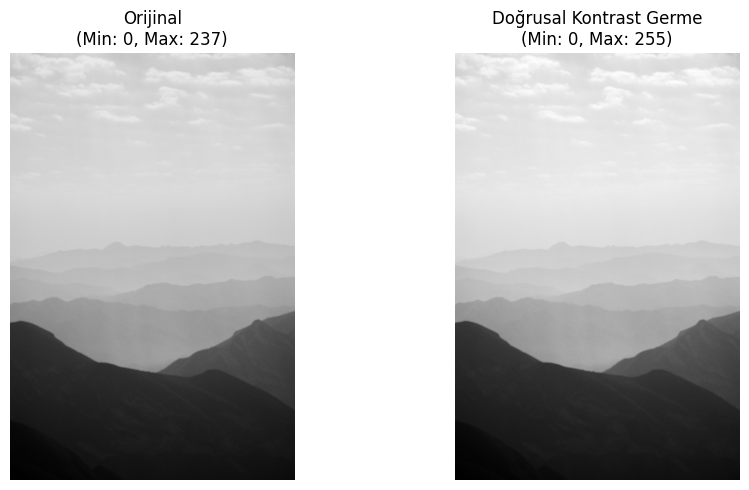

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('manzara.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Resim bulunamadı, test için 80 ile 160 değerleri arasında yapay resim üretiliyor...")
    img = np.random.randint(80, 160, (400, 400), dtype=np.uint8)

yukseklik, genislik = img.shape

min_deger = 255
max_deger = 0

for i in range(yukseklik):
    for j in range(genislik):
        piksel = img[i, j]
        if piksel < min_deger:
            min_deger = piksel
        if piksel > max_deger:
            max_deger = piksel

print(f"Orijinal Resim - Minimum Değer: {min_deger}, Maksimum Değer: {max_deger}")

germe_img = np.zeros((yukseklik, genislik), dtype=np.uint8)

if max_deger == min_deger:
    print("Maksimum ve minimum değerler aynı, germe işlemi yapılamaz!")
    germe_img = img.copy()
else:
    for i in range(yukseklik):
        for j in range(genislik):
            eski_piksel = img[i, j]
            yeni_piksel = ((eski_piksel - min_deger) / (max_deger - min_deger)) * 255

            germe_img[i, j] = max(0, min(255, int(round(yeni_piksel))))

yeni_min = np.min(germe_img)
yeni_max = np.max(germe_img)
print(f"Gerilmiş Resim - Minimum Değer: {yeni_min}, Maksimum Değer: {yeni_max}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title(f"Orijinal\n(Min: {min_deger}, Max: {max_deger})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(germe_img, cmap='gray', vmin=0, vmax=255)
plt.title(f"Doğrusal Kontrast Germe\n(Min: {yeni_min}, Max: {yeni_max})")
plt.axis('off')

plt.tight_layout()
plt.show()